# Research question 4: can a field be added by configuration alone

An organisation adopting the system will want fields the original schema never had. In Insight a schema is a versioned configuration file, not code, so adding a field should require exactly one new file and a restart.

Schema v2 equals v1 plus one new field, `banking_task` (eight closed values, the bank-call task types). The 50 hvb calls were re-processed under v2, with no retraining and no code change. Gold needed no annotation: the corpus labels every call's task.

The numbers come from `evaluation/rq4/out/` (produced by `evaluation/run.py`).

In [1]:
# The repository root is the first parent directory holding docker-compose.yml
import json
from pathlib import Path

REPO = Path.cwd().resolve()
while not REPO.joinpath("docker-compose.yml").exists():
  REPO = REPO.parent

OUT = REPO.joinpath("evaluation", "rq4", "out")
print("reading from:", OUT)

reading from: /home/amed/uni/insight/evaluation/rq4/out


## The scores

Why this output: these numbers judge whether a configuration-added field reached usable accuracy, and show P1 refusing by design.

- `banking_task` accuracy of the configuration-added field (50 calls, gold from the corpus task labels)
- `intent` accuracy of an original field on the same calls, the comparison anchor for the 10-point criterion
- `validity` share of all six v2 fields whose first answer was a legal schema value; a coercion on any field counts against it
- `supported_claims` banking_task claims backed by at least one citation
- p1's `failed` count is the designed refusal, not an error

In [2]:
scores_file = OUT.joinpath("scores.json")
if not scores_file.exists():
  print("no rq4 scores yet; run evaluation/run.py first")
else:
  scores = json.loads(scores_file.read_text())
  print(f"p1 refusal: {scores['p1']['failed']} of {scores['p1']['cells']} cells failed (designed)\n")
  print(f"{'pipeline':<9} {'banking_task':<13} {'intent':<8} {'validity':<9} supported_claims")
  for pipeline in ("p2", "p3"):
    s = scores[pipeline]
    banking = f"{s['banking_task_accuracy']:.2f}" if s["banking_task_accuracy"] is not None else "-"
    intent = f"{s['intent_accuracy']:.2f}" if s["intent_accuracy"] is not None else "-"
    validity = f"{s['validity']:.3f}" if s["validity"] is not None else "-"
    print(f"{pipeline:<9} {banking:<13} {intent:<8} {validity:<9} {s['supported_banking_claims']}")
  print("\npre-committed criteria, judged:")
  print(json.dumps(scores["criteria"], indent=1))

p1 refusal: 50 of 50 cells failed (designed)

pipeline  banking_task  intent   validity  supported_claims
p2        0.64          0.12     1.000     32
p3        0.46          0.46     1.000     23

pre-committed criteria, judged:
{
 "validity_ge_95": {
  "p2": {
   "validity": 1.0,
   "met": true
  },
  "p3": {
   "validity": 1.0,
   "met": true
  }
 },
 "banking_within_10_of_intent": {
  "p2": {
   "banking_task": 0.64,
   "intent": 0.11538461538461539,
   "met": true
  },
  "p3": {
   "banking_task": 0.46,
   "intent": 0.46153846153846156,
   "met": true
  }
 }
}


## The picture

Why this output: if the two groups reach similar heights, configuration alone produced a usable field. P1 has no bars, it refused every v2 record by design.

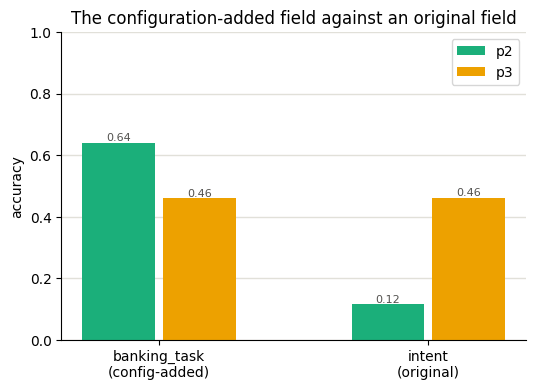

In [3]:
import matplotlib.pyplot as plt

COLORS = {"p2": "#1baf7a", "p3": "#eda100"}
FIELDS = (
  ("banking_task_accuracy", "banking_task\n(config-added)"),
  ("intent_accuracy", "intent\n(original)"),
)

if not scores_file.exists():
  print("no rq4 scores yet; run evaluation/run.py first")
else:
  scores = json.loads(scores_file.read_text())

  fig, ax = plt.subplots(figsize=(6, 4))
  for offset, pipeline in enumerate(("p2", "p3")):
    xs = []
    ys = []
    for index, (key, label) in enumerate(FIELDS):
      if scores[pipeline][key] is not None:
        xs.append(index + (offset - 0.5) * 0.3)
        ys.append(scores[pipeline][key])
    ax.bar(xs, ys, width=0.27, color=COLORS[pipeline], label=pipeline)
    for x, y in zip(xs, ys):
      ax.text(x, y, f"{y:.2f}", ha="center", va="bottom", fontsize=8, color="#52514e")

  ax.set_xticks(range(len(FIELDS)))
  ax.set_xticklabels([label for key, label in FIELDS])
  ax.set_ylim(0, 1)
  ax.set_ylabel("accuracy")
  ax.set_title("The configuration-added field against an original field")
  ax.legend()
  ax.grid(axis="y", color="#e1e0d9", linewidth=1)
  ax.set_axisbelow(True)
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  plt.show()

## What to conclude

rq4's answer has two halves.

**The numerical half**: if both criteria hold, a field added purely by configuration reached usable accuracy with evidential support, without touching code or models.

**The architectural half** is already decided: P1 refused every v2 record because its trained artifact claims schema v1, which is the honest behaviour for a supervised model facing a schema it was never trained on.

Extension by configuration is a property of the schema-driven pipelines, not of the classifier. The machine-readable numbers live in `evaluation/rq4/out/scores.json` and `results.csv`.